# Xarray-Spatial Interpolation: Ordinary kriging

Kriging turns scattered point measurements into a continuous surface by fitting a spatial correlation model (variogram) to the data. It also gives you a per-pixel uncertainty estimate, something most interpolation methods skip. That makes it a natural fit for soil surveys, environmental monitoring, and any setting where you need to know both the prediction and how much you should trust it.

### What you'll build

1. Generate scattered sample points from a known surface
2. Reconstruct the full field with `kriging` and compare it to the ground truth
3. Map prediction uncertainty with kriging variance
4. Compare spherical, exponential, and Gaussian variogram models
5. Apply kriging to a practical soil-property mapping scenario

![Kriging interpolation preview](images/kriging_preview.png)

[Sample data](#Sample-data) · [Basic interpolation](#Basic-interpolation) · [Kriging variance](#Kriging-variance) · [Variogram models](#Variogram-models) · [Soil property mapping](#Soil-property-mapping)

Standard imports plus `kriging` from the interpolation module.

In [1]:
%matplotlib inline
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from xrspatial.interpolate import kriging

## Sample data

We need a known surface to test against so we can see how well kriging recovers it. The surface is `z = sin(x) * cos(y)` with a small amount of Gaussian noise added to 40 random sample points. The output grid is 60x60 cells covering the same domain.

In [2]:
# True surface: z = sin(x) * cos(y)
rng = np.random.RandomState(42)
n_pts = 40
x_pts = rng.uniform(0, 6, n_pts)
y_pts = rng.uniform(0, 6, n_pts)
z_pts = np.sin(x_pts) * np.cos(y_pts) + rng.normal(0, 0.05, n_pts)

# Output grid
x_grid = np.linspace(0, 6, 60)
y_grid = np.linspace(0, 6, 60)
template = xr.DataArray(
    np.zeros((len(y_grid), len(x_grid))),
    dims=['y', 'x'],
    coords={'y': y_grid, 'x': x_grid},
)

# True surface as a DataArray for plotting
gx, gy = np.meshgrid(x_grid, y_grid)
true_surface = xr.DataArray(
    np.sin(gx) * np.cos(gy),
    dims=['y', 'x'],
    coords={'y': y_grid, 'x': x_grid},
)

The true surface has smooth peaks and valleys. The 40 sample points are scattered randomly across the domain. The plot below shows the underlying truth with sample locations overlaid.

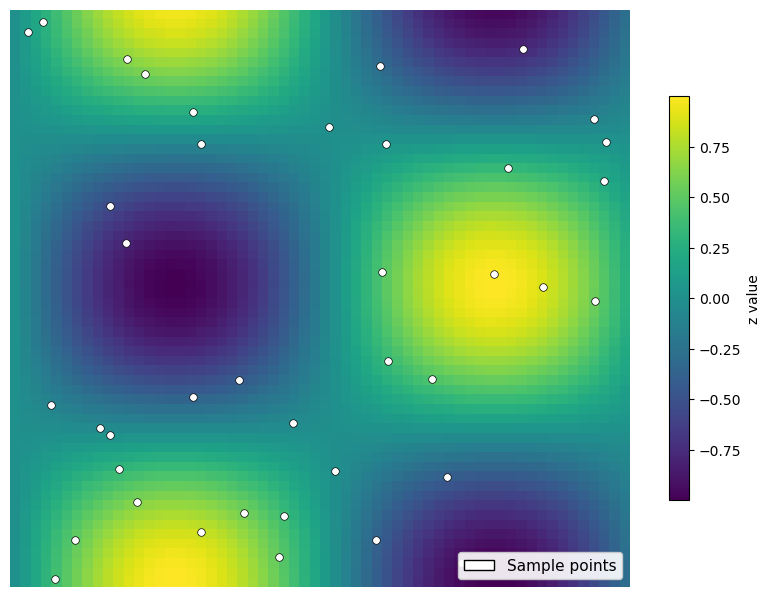

In [3]:
fig, ax = plt.subplots(figsize=(10, 7.5))
true_surface.plot.imshow(ax=ax, cmap='viridis', add_colorbar=True,
                         cbar_kwargs={'label': 'z value', 'shrink': 0.7})
ax.scatter(x_pts, y_pts, c='white', s=30, edgecolors='black', linewidth=0.5, zorder=5)
ax.legend(handles=[Patch(facecolor='white', edgecolor='black', label='Sample points')],
          loc='lower right', fontsize=11, framealpha=0.9)
ax.set_axis_off()

## Basic interpolation

`kriging` takes the scattered point coordinates, their measured values, and a template DataArray that defines the output grid. Under the hood it fits an [experimental variogram](https://en.wikipedia.org/wiki/Variogram) to characterize how spatial correlation decays with distance, then uses it to weight nearby observations for each grid cell.

The plot below puts the kriging prediction side by side with the true surface.

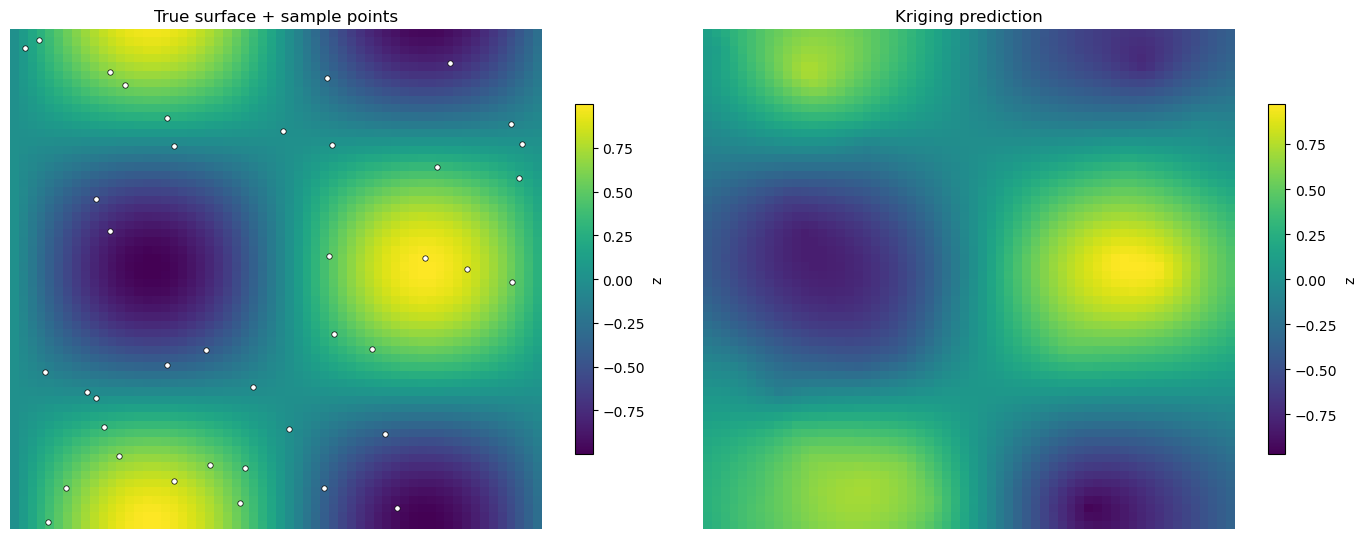

In [4]:
result = kriging(x_pts, y_pts, z_pts, template)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

true_surface.plot.imshow(ax=axes[0], cmap='viridis', add_colorbar=True,
                         cbar_kwargs={'label': 'z', 'shrink': 0.7})
axes[0].scatter(x_pts, y_pts, c='white', s=15, edgecolors='black', linewidth=0.5, zorder=5)
axes[0].set_title('True surface + sample points')
axes[0].set_axis_off()

result.plot.imshow(ax=axes[1], cmap='viridis', add_colorbar=True,
                   cbar_kwargs={'label': 'z', 'shrink': 0.7})
axes[1].set_title('Kriging prediction')
axes[1].set_axis_off()

plt.tight_layout()

## Kriging variance

Set `return_variance=True` and `kriging` returns a `(prediction, variance)` tuple. The variance map tells you where the prediction is well-constrained by nearby observations and where it is extrapolating. Low variance near sample points, high variance in gaps.

The plot shows the prediction on the left and variance on the right, with sample locations marked.

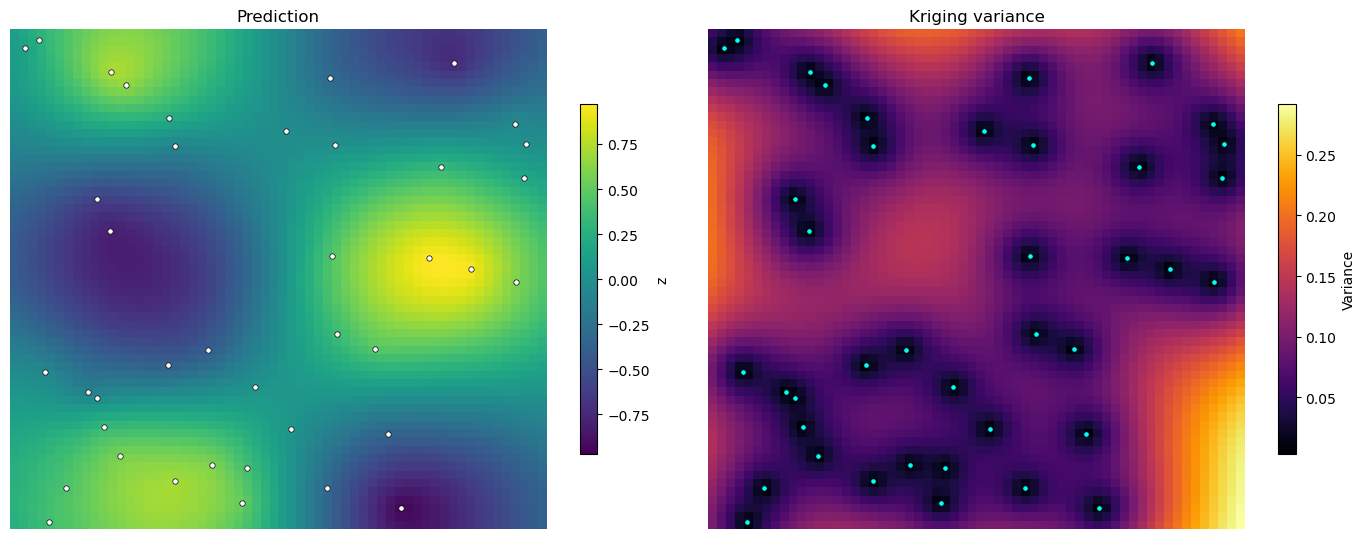

In [5]:
pred, var = kriging(x_pts, y_pts, z_pts, template, return_variance=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

pred.plot.imshow(ax=axes[0], cmap='viridis', add_colorbar=True,
                 cbar_kwargs={'label': 'z', 'shrink': 0.7})
axes[0].scatter(x_pts, y_pts, c='white', s=15, edgecolors='black', linewidth=0.5, zorder=5)
axes[0].set_title('Prediction')
axes[0].set_axis_off()

var.plot.imshow(ax=axes[1], cmap='inferno', add_colorbar=True,
                cbar_kwargs={'label': 'Variance', 'shrink': 0.7})
axes[1].scatter(x_pts, y_pts, c='cyan', s=15, edgecolors='black', linewidth=0.5, zorder=5)
axes[1].set_title('Kriging variance')
axes[1].set_axis_off()

plt.tight_layout()

<div class="alert alert-block alert-warning">
<b>Variance is not error.</b> Kriging variance reflects the geometry of the sample network relative to the variogram model. It does not account for model misspecification, measurement error beyond what the nugget captures, or non-stationarity. Treat it as a relative confidence indicator, not an absolute error bound.
</div>

## Variogram models

The `variogram_model` parameter picks the shape of the [spatial correlation function](https://en.wikipedia.org/wiki/Variogram#Variogram_models). xrspatial supports three: `spherical` (reaches a hard sill), `exponential` (approaches the sill asymptotically), and `gaussian` (smooth near the origin). The choice affects how nearby vs. distant points are weighted.

Below we run all three on the same sample data so you can compare.

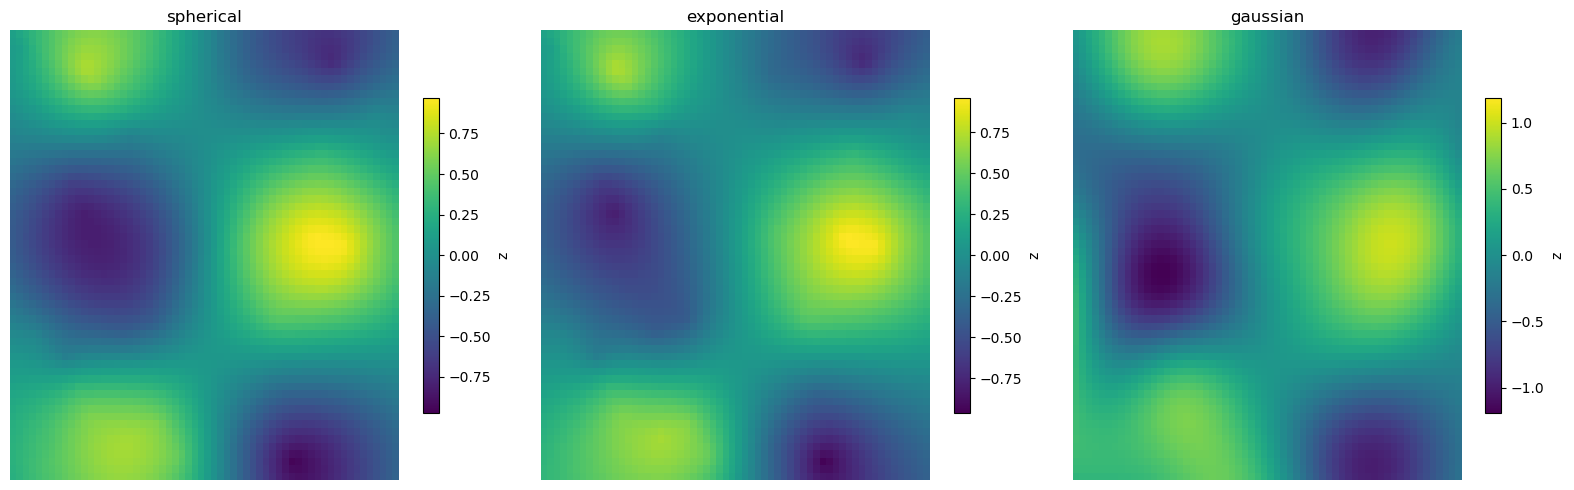

In [6]:
models = ['spherical', 'exponential', 'gaussian']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, model in zip(axes, models):
    r = kriging(x_pts, y_pts, z_pts, template, variogram_model=model)
    r.plot.imshow(ax=ax, cmap='viridis', add_colorbar=True,
                  cbar_kwargs={'label': 'z', 'shrink': 0.7})
    ax.set_title(model)
    ax.set_axis_off()

plt.tight_layout()

## Soil property mapping

A more realistic scenario: 50 soil pH measurements collected at random locations across a 100 m field. There is a spatial trend (pH increases toward the northeast) plus random variation. Kriging picks up the trend and fills the gaps, while the variance map flags the corners and edges where samples are thin.

The left panel shows the predicted pH surface with the original sample values overlaid. The right panel shows where uncertainty is highest.

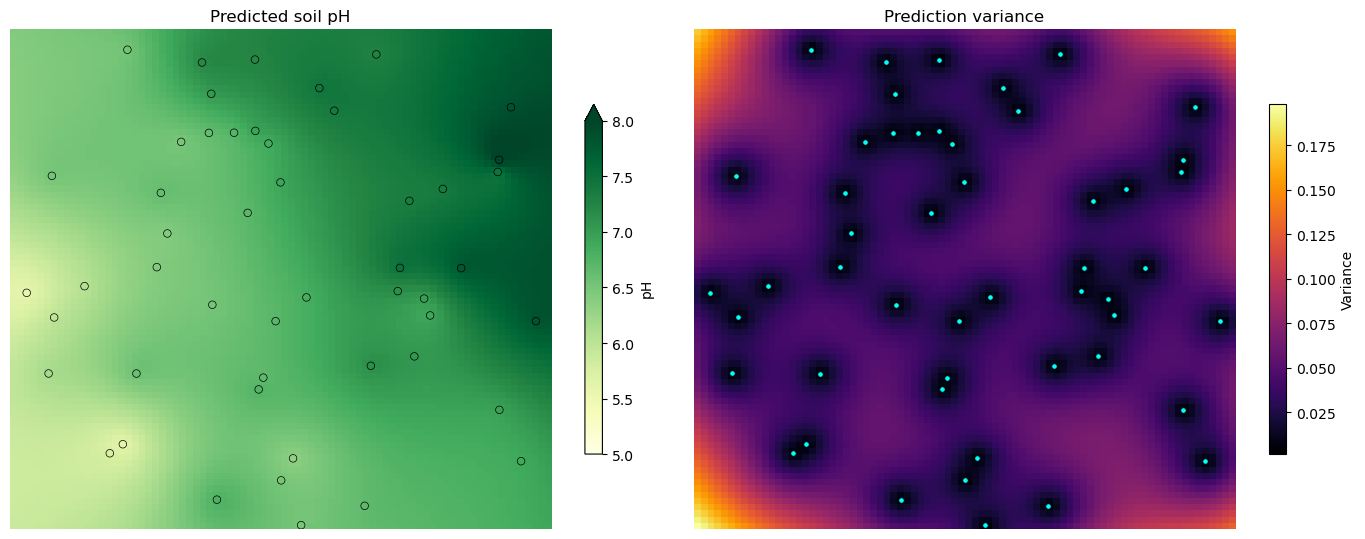

In [7]:
# Simulated soil pH: smooth trend + noise
rng_soil = np.random.RandomState(7)
n_samples = 50
x_soil = rng_soil.uniform(0, 100, n_samples)
y_soil = rng_soil.uniform(0, 100, n_samples)
ph = 5.5 + 0.015 * x_soil + 0.010 * y_soil + rng_soil.normal(0, 0.3, n_samples)

# Prediction grid
xg = np.linspace(0, 100, 80)
yg = np.linspace(0, 100, 80)
template_soil = xr.DataArray(
    np.zeros((len(yg), len(xg))),
    dims=['y', 'x'],
    coords={'y': yg, 'x': xg},
)

ph_pred, ph_var = kriging(
    x_soil, y_soil, ph, template_soil,
    variogram_model='spherical', return_variance=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ph_pred.plot.imshow(ax=axes[0], cmap='YlGn', vmin=5, vmax=8,
                    add_colorbar=True,
                    cbar_kwargs={'label': 'pH', 'shrink': 0.7})
axes[0].scatter(x_soil, y_soil, c=ph, cmap='YlGn', vmin=5, vmax=8,
                s=30, edgecolors='black', linewidth=0.5, zorder=5)
axes[0].set_title('Predicted soil pH')
axes[0].set_axis_off()

ph_var.plot.imshow(ax=axes[1], cmap='inferno',
                   add_colorbar=True,
                   cbar_kwargs={'label': 'Variance', 'shrink': 0.7})
axes[1].scatter(x_soil, y_soil, c='cyan', s=15, edgecolors='black', linewidth=0.5, zorder=5)
axes[1].set_title('Prediction variance')
axes[1].set_axis_off()

plt.tight_layout()

The pH map picks up the northeast trend from the raw observations. Variance is lowest in the center of the field where samples are dense and highest near the edges, exactly what you would use to decide where to collect additional samples.

<div class="alert alert-block alert-info">
<b>Ordinary vs. universal kriging.</b> This implementation performs ordinary kriging, which assumes a constant (unknown) mean across the domain. If your data has a strong spatial trend (like the pH gradient here), consider detrending first and kriging the residuals. That gives the variogram a stationary signal to work with rather than mixing trend and correlation.
</div>

In [8]:
# Save preview image for the "What you'll build" cell
import os as _os

_fig, _axes = plt.subplots(1, 2, figsize=(14, 5.5))
pred.plot.imshow(ax=_axes[0], cmap='viridis', add_colorbar=True,
                 cbar_kwargs={'label': 'z', 'shrink': 0.7})
_axes[0].scatter(x_pts, y_pts, c='white', s=15, edgecolors='black', linewidth=0.5, zorder=5)
_axes[0].set_title('Kriging prediction')
_axes[0].set_axis_off()
var.plot.imshow(ax=_axes[1], cmap='inferno', add_colorbar=True,
                cbar_kwargs={'label': 'Variance', 'shrink': 0.7})
_axes[1].scatter(x_pts, y_pts, c='cyan', s=15, edgecolors='black', linewidth=0.5, zorder=5)
_axes[1].set_title('Kriging variance')
_axes[1].set_axis_off()
_fig.tight_layout()
_img_dir = _os.path.join(_os.path.dirname(_os.path.abspath('__file__')), 'images')
_os.makedirs(_img_dir, exist_ok=True)
_fig.savefig(_os.path.join(_img_dir, 'kriging_preview.png'), bbox_inches='tight', dpi=120)
plt.close(_fig)
del _fig, _axes, _img_dir

### References

- [Kriging](https://en.wikipedia.org/wiki/Kriging), Wikipedia
- [Variogram](https://en.wikipedia.org/wiki/Variogram), Wikipedia
- Cressie, N. (1993). *Statistics for Spatial Data*. Wiley.
- Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press.